In [1]:
from e3nn import o3
from e3nn.o3 import Irreps, FullyConnectedTensorProduct, spherical_harmonics
from e3nn.o3._linear import Linear
from e3nn.nn import Gate, FullyConnectedNet

import torch
from torch import nn
from torch.optim.lr_scheduler import CosineAnnealingLR

import numpy as np
from numpy.typing import NDArray

from scipy.spatial import cKDTree

from torch_geometric.data import Data
from torch_geometric.utils import scatter
from torch.optim import AdamW
from torch.utils.data import Dataset

from ovito.io import import_file

import pandas as pd

import os
import time
from typing import Any, cast
from tqdm import tqdm

import random

# 1e-8 --> 1e-12
# Completely remove alpha

In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

NUM_NEIGHBORS = 16
BATCH_SIZE = 1024
EPOCHS = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Edge Embedding

We will use a slightly modified version of the NequIP and Dimenet node embedding that is the same as the one used by the denoiser.

$$
B(r)=\sqrt{\frac{2}{r_c}} \frac{\sin\left({\frac{n \pi r}{r_c}}\right)}{r}
$$

where $r$ is the edge distance, $r_c$ is the cutoff, and $n$ ($1$-indexed) is the $n$-th element of the embedding.

In [3]:
def bessel(r: torch.Tensor, n: int, r_c: float = 2.0, p: float = 6.0) -> torch.Tensor:
    """
    Params:
        r: tensor of shape (B, 1)
    """
    sin_cmp = ((2 / r_c) ** 0.5) * torch.sin(r * torch.pi * torch.arange(1, n + 1, device=r.device) / r_c) / (r + 1e-8)

    # r_norm = r / r_c
    # fenv = 1 - ((p + 1) * (p + 2)) / 2 * r_norm.pow(p) + p * (p + 2) * r_norm.pow(p + 1) - p * (p + 1) / 2 * r_norm.pow(p + 2)
    
    # Zero out any r >= r_c
    # fenv = torch.where(r_norm <= 1.0, fenv, torch.zeros_like(fenv))

    # (B, 1) (Note: (B, 1) x (n,) -> (B, n))
    return sin_cmp # * fenv
    

### Model

The implementation is inspired by the denoiser's implementation but a little more faithful to the original NequIP paper.

In [4]:
class InteractionBlock(nn.Module):
    def __init__(
        self,
        irreps_in: Irreps,
        irreps_out: Irreps,

        irreps_node_frozen: Irreps,
        irreps_edge_sph: Irreps,

        edge_dist_n: int,
        radial_hidden: int,
    ) -> None:
        super().__init__()
        
        # Convolution for a single edge
        # Each (mul, l_in) x (singular l_filter Y) -> (mul, l_out)
        # There will be mul paths with in the instruction so it will contain
        # mul different weights 

        irreps_mid = []
        instructions = []
        weights_count = 0

        for i, (mul, ir_in) in enumerate(irreps_in):
            for j, (_, ir_edge) in enumerate(irreps_edge_sph):
                for ir_out in ir_in * ir_edge:
                    if ir_out in irreps_out:
                        irreps_mid.append((mul, ir_out))
                        instructions.append((i, j, len(irreps_mid) - 1, "uvu", True))
                        weights_count += mul

        irreps_mid = o3.Irreps(irreps_mid)
        irreps_mid, p, _ = irreps_mid.sort()

        instructions = [
            (i, j, p[k], mode, train)
            for i, j, k, mode, train in instructions
        ]

        self.conv = o3.TensorProduct(
            irreps_in,
            irreps_edge_sph,
            irreps_mid,
            instructions,
            internal_weights = False,
            shared_weights = False,
        )
        assert weights_count == self.conv.weight_numel

        # Linear layer before the convolution (channel mixing)
        self.lin1 = Linear(
            irreps_in=irreps_in,
            irreps_out=irreps_in,
        )

        # Linear layer after the convolution (shrinks down to output as well)
        self.lin2 = Linear(
            irreps_in=irreps_mid.simplify(), # Should work since sorted -- affects normalization?
            irreps_out=irreps_out
        )

        # Edge MLP
        self.edge_mlp = FullyConnectedNet([edge_dist_n, radial_hidden, weights_count], nn.SiLU())
        
        # Self connection
        self.sc = FullyConnectedTensorProduct(
            irreps_in,
            irreps_node_frozen,
            irreps_out,
        )

        # Learned weighting
        # self.alpha = o3.Linear(irreps_in, "1x0e")
        # with torch.no_grad():
            # self.alpha.weight.zero_()
    
    def forward(self, node_emb_in, node_emb_frozen, edge_index, edge_sph, edge_emb):
        # Basic info
        nodes = node_emb_in.shape[0]

        row, col = edge_index
        skip = self.sc(node_emb_in, node_emb_frozen)
        deg = scatter(src=torch.ones_like(row), index=col, dim=0, dim_size=nodes, reduce="sum")
        
        # Self interaction, conv + concat, self interaction
        node_vals = self.lin1(node_emb_in)
        edge_messages = self.conv(node_vals[row], edge_sph, weight=self.edge_mlp(edge_emb))

        # Deviation: mean rather than sqrt
        message_agg = scatter(edge_messages, col, dim=0, dim_size=nodes, reduce="sum") / deg.unsqueeze(-1).clamp(min=1.0)
        
        node_result = self.lin2(message_agg)

        # gate = torch.tanh(self.alpha(node_emb_in))
        return skip + node_result # Remove gating for now
        # return skip + gate * node_result

In [5]:
class NequIP(nn.Module):
    def __init__(
        self,
        num_species: int = 1,
        node_embedding_init: int = 8, # {node_embedding_init}x0e
        node_embedding_frozen: int = 8, # {node_embedding_frozen}x0e

        irreps_edge_sph: Irreps = Irreps("1x0e + 1x1e + 1x2e"),
        edge_dist_n: int = 8, # CHANGED
        radial_hidden: int = 32, # CHANGED

        irreps_hidden: Irreps = Irreps("8x0e + 8x1e + 8x2e"), # CHANGED
        num_convs: int = 3,

        invariant_latent_size = 32,
        output_classes = 6, #{output_classes}x0e

        node_dropout = 0.05,
        edge_dropout = 0.10,
    ) -> None:
        super().__init__()
        
        # Our use case only requires even irreps
        for _, ir in irreps_hidden + irreps_edge_sph:
            assert ir.p == 1, "we assume that all irreps are even"

        self.embedding_frozen = nn.Embedding(num_species, node_embedding_frozen)
        self.embedding_init = nn.Embedding(num_species, node_embedding_init)
        
        self.irreps_edge_sph = irreps_edge_sph
        self.edge_dist_n = edge_dist_n

        self.node_dropout = node_dropout
        self.edge_dropout = edge_dropout

        self.layers_core = nn.ModuleList()
        self.layers_gate = nn.ModuleList()

        for i in range(num_convs):
            # Everything here is based on the assumption of even irreps and
            # existant of a path to the 0xe output in the interaction block core
            scalars = 0
            gates = 0
            gated = []

            for (mul, ir) in irreps_hidden:
                if ir.l == 0:
                    scalars += mul
                else:
                    gates += mul
                    gated.append((mul, ir))
            
            gate = Gate(
                f"{scalars}x0e", 
                [nn.SiLU()], 
                f"{gates}x0e",
                [nn.Sigmoid()],
                Irreps(gated)
            )
            assert gate.irreps_out == irreps_hidden, "output of gate should be hidden"

            self.layers_core.append(InteractionBlock(
                irreps_in=Irreps(f"{node_embedding_init}x0e") if i == 0 else irreps_hidden,
                irreps_out=gate.irreps_in,
                irreps_node_frozen=Irreps(f"{node_embedding_frozen}x0e"),
                irreps_edge_sph=irreps_edge_sph,
                edge_dist_n=edge_dist_n,
                radial_hidden=radial_hidden,
            ))
            self.layers_gate.append(gate)

        assert len(self.layers_core) == len(self.layers_gate) == num_convs

        self.to_inv_embedding = FullyConnectedTensorProduct(
            irreps_hidden, 
            irreps_hidden, 
            f"{invariant_latent_size}x0e"
        )
        self.pre_head_act = nn.SiLU()
        self.head = nn.Linear(invariant_latent_size, output_classes)

    def forward(self, data: Data):
        # Node and edge dropout
        if self.training:
            non_center = ~data.center_mask
            drop_node_mask = ((torch.rand(non_center.shape[-1], device=data.x.device) < self.node_dropout) & non_center)
            data = data.subgraph(~drop_node_mask)

            drop_edge_mask = (torch.rand(data.edge_index.shape[-1], device=data.x.device) < self.edge_dropout)
            data.edge_index = data.edge_index[:, ~drop_edge_mask]

        # We let data.x just be the species
        node_emb = self.embedding_init(data.x)
        frozen_emb = self.embedding_frozen(data.x)

        # Prepare edge info
        row, col = data.edge_index

        # In message passing, we pass along j --> i yet vectors should be relative
        # to central atom i so we need to use vector corresponding to i --> j which
        # is why we invert by subtracting the target from the source. 
        edge_vecs = data.pos[row] - data.pos[col]
        edge_dists = edge_vecs.norm(dim=-1, keepdim=True)
            
        edge_sph = spherical_harmonics(
            self.irreps_edge_sph,
            edge_vecs, 
            normalize=True, 
            normalization="component"
        )
        edge_emb = bessel(edge_dists, self.edge_dist_n)
        
        # Go through layers
        for core, gate in zip(self.layers_core, self.layers_gate):
            node_emb = core(node_emb, frozen_emb, data.edge_index, edge_sph, edge_emb)
            node_emb = gate(node_emb)
            
        # Classification of center nodes and node embeddings (note: the embeddings 
        # themselves are equivariant) so use them carefully
        final_eq_embeddings = node_emb[data.center_mask]
        average_eq_embeddings_per_graph = scatter(node_emb, data.batch, dim=0, reduce="mean")

        inv_embeddings = self.to_inv_embedding(final_eq_embeddings, average_eq_embeddings_per_graph)
        inv_embeddings = inv_embeddings / (inv_embeddings.norm(dim=-1, keepdim=True) + 1e-8)

        return self.head(self.pre_head_act(inv_embeddings)), inv_embeddings

### Graph Creation

In [6]:
def construct_graph_lists(
    pos_individual: NDArray[np.number[Any]], num_neighbors: int, cell: NDArray[np.number] | None = None
) -> tuple[NDArray[np.number[Any]], NDArray[np.number[Any]]]:

    pos_individual = np.asarray(pos_individual, dtype=np.float32)
    if pos_individual.ndim != 2 or pos_individual.shape[1] != 3:
        raise ValueError("pos_individual must be a 2D array with shape (N, 3)")
    
    if cell is not None:
        boxsize = np.max(cell[:, :3], axis=1)
        pos_individual -= cell[:, 3]
        pos_individual %= boxsize
        try:
            tree = cKDTree(pos_individual, boxsize=boxsize)
        except:
            print("Warning: outside box")
            tree = cKDTree(pos_individual)
    else:
        tree = cKDTree(pos_individual)
    neighbors = tree.query(pos_individual, k=num_neighbors + 1)[1]

    # Each data entry will store all nearest neighbor positions with the first one being the central atom
    pos_graph = pos_individual[neighbors]
    pos_graph = cast(NDArray[np.number[Any]], pos_graph)
    
    if cell is not None:
        for group in pos_graph:
            anchor = group[0]
            group -= anchor
            pbc_fact = boxsize * np.round(group / boxsize)
            group -= pbc_fact
    assert np.all(neighbors[:, 0] == np.arange(len(pos_individual)))

    return neighbors, pos_graph

In [7]:
def normalize_position_batch(pos_graphs: torch.tensor, edge_index_single: torch.tensor) -> torch.tensor:
    diffs = pos_graphs[:, edge_index_single[1], :] - pos_graphs[:, edge_index_single[0], :]
    # diffs = pos_graphs[:, 1:, :] - pos_graphs[:, 0:1, :]
    
    dists = diffs.norm(dim=-1)
    mean_edge_len = dists.mean(dim=-1, keepdim=True)
    # mean_edge_len = dists.max(dim=-1, keepdim=True).values

    if torch.any(mean_edge_len == 0):
        raise ValueError("One of the graphs has zero mean edge length.")
    
    return pos_graphs / mean_edge_len.unsqueeze(-1)

def create_complete_graph_edges_single(num_nodes: int, device: str) -> torch.tensor:
    row = torch.arange(0, num_nodes, device=device).repeat_interleave(num_nodes - 1).long()
    col = torch.cat([torch.cat((torch.arange(0, i, device=device), torch.arange(i + 1, num_nodes, device=device))) for i in range(0, num_nodes)]).long()
    return torch.stack([row, col])

def create_center_mask_single(num_nodes: int, device: str) -> torch.tensor:
    center_mask = torch.zeros(num_nodes, device=device).bool()
    center_mask[0] = True
    return center_mask

In [8]:
def construct_batched_graph(pos_graphs: torch.tensor, label_ints: torch.Tensor | None, calc_device: str) -> Data:
    pos_graphs = pos_graphs.to(calc_device)
    batches, num_nodes_single = pos_graphs.shape[0], pos_graphs.shape[1]
    num_edges = num_nodes_single * num_nodes_single - num_nodes_single

    # Complete graph with all edges relating to 0 (center) taking up the prefix
    edge_index_single = create_complete_graph_edges_single(num_nodes_single, calc_device)
    offsets = (torch.arange(batches, device=calc_device) * num_nodes_single).view(1, -1, 1)
    edge_index_all = (edge_index_single.view(2, 1, num_edges) + offsets).reshape(2, batches * num_edges)

    # Normalize positions
    pos_norm_batched = normalize_position_batch(pos_graphs, edge_index_single).reshape(batches * num_nodes_single, 3)

    # Mask
    center_mask = create_center_mask_single(num_nodes_single, calc_device).repeat(batches)
    
    # Initial embeddings
    emb = torch.zeros(batches * num_nodes_single, dtype=torch.long, device=calc_device)

    # Batch
    batch = torch.arange(0, batches, device=calc_device).repeat_interleave(num_nodes_single)

    return Data(
        x=emb,
        num_nodes=batches * num_nodes_single,
        pos=pos_norm_batched,
        edge_index=edge_index_all,
        center_mask=center_mask,
        batch=batch,
        y=label_ints
    ).cpu()

In [9]:
x_data_temp = []
y_data = []

all_vals = []
for structure in os.listdir("synthetic_data"):
    for f in os.listdir(os.path.join("synthetic_data", structure)):
        pipeline = import_file(os.path.join("synthetic_data", structure, f))
        lattice = pipeline.compute()

        all_positions = np.copy(lattice.particles.positions)
        _, graph = construct_graph_lists(all_positions, NUM_NEIGHBORS, lattice.cell)

        x_data_temp.append(graph)
        y_data.extend([structure] * len(all_positions))

x_data = np.concat(x_data_temp)
label_map = {label: i for i, label in enumerate(sorted(set(y_data)))}

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'synthetic_data'

### Dataset

In [11]:
class CrystalDataset(Dataset):
    def __init__(self, pos_graphs: np.ndarray, label_strs: list[str] | None, label_map: list[str] | None):
        self.pos_graphs = torch.from_numpy(pos_graphs).float()
        self.label_map = label_map
        self.label_ints = torch.tensor([self.label_map[label] for label in label_strs]).long() if label_strs is not None else None

    def __len__(self):
        return self.pos_graphs.shape[0]
        
    def __getitem__(self, idx: int | slice | list[int] | torch.Tensor) -> tuple[torch.Tensor, torch.Tensor | None]:
        pos_graphs_ret = self.pos_graphs[idx].contiguous()
        label_ints_ret = self.label_ints[idx].contiguous() if self.label_ints is not None else None
        return pos_graphs_ret, label_ints_ret

class FastLoader:
    def __init__(self, dataset: CrystalDataset, batch_size: int, calc_device: str, shuffle: bool):
        self.dataset = dataset
        self.batch_size = batch_size
        self.calc_device = calc_device
        self.shuffle = shuffle
        self.num_batches = (len(dataset) + batch_size - 1) // batch_size
    
    def __len__(self):
        return self.num_batches
    
    def __iter__(self):
        indices = torch.arange(len(self.dataset))

        if self.shuffle:
            indices = indices[torch.randperm(len(indices))]

        for start in range(0, len(indices), self.batch_size):
            batch_indices = indices[start : start + self.batch_size]
            pos_graphs, label_ints = self.dataset[batch_indices]

            yield construct_batched_graph(pos_graphs, label_ints, self.calc_device)

### Training

In [ ]:
set_seed(42)

num_data = x_data.shape[0]
train_section = int(0.8 * num_data)

use_indices = np.random.choice(len(x_data), size=num_data, replace=False)
train_indices = use_indices[0 : train_section]
test_indices = use_indices[train_section : num_data]

train_dataset = CrystalDataset(x_data[train_indices], [y_data[i] for i in train_indices], label_map)
test_dataset = CrystalDataset(x_data[test_indices], [y_data[i] for i in test_indices], label_map)

train_loader = FastLoader(train_dataset, BATCH_SIZE, device, shuffle=True)
test_loader = FastLoader(test_dataset, BATCH_SIZE, device, shuffle=False)

In [10]:
y_int = np.array([label_map[y] for y in y_data])
class_counts = np.bincount(y_int)
inv_freq = 1.0 / class_counts
weights = torch.tensor(inv_freq / inv_freq.mean(), device=device).float()
print(weights)

TypeError: Cannot cast array data from dtype('float64') to dtype('int64') according to the rule 'safe'

In [29]:
model = NequIP().to(device)

criterion = nn.CrossEntropyLoss(weights, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-4)

In [14]:
N_USE = 17000
def compute_feature_for_simulation(file_info):
    np.random.seed(42)
    exp_name, file_name = file_info
    file_path = f"data/{exp_name}/{file_name}"
    pipeline = import_file(file_path)
    num_frames = pipeline.source.num_frames
    dat = []
    for frame in range(num_frames):
        lattice = pipeline.compute(frame)
        lattice = pipeline.compute()
        all_positions = np.copy(lattice.particles.positions)
        _, graph = construct_graph_lists(all_positions, NUM_NEIGHBORS, lattice.cell)
        dat.extend(graph)
        """
        lattice = pipeline.compute(frame)
        lattice = pipeline.compute()
        all_positions = np.copy(lattice.particles.positions)
        tree = cKDTree(all_positions)
        neighbors = tree.query(all_positions, k=16 + 1)[1][:]
        for neigh in neighbors:
            dat.append(np.array([all_positions[i] for i in neigh]))
        """
    dat = np.array(dat)
    np.random.shuffle(dat)
    return dat[0 : 17000]
md_testing_data = []
md_data_loader = []
for exp in ["dump_0.24.gz", "dump_0.36.gz", "dump_0.96.gz", "dump_1.12.gz"]:
    md_testing_data.append(compute_feature_for_simulation(("al_fcc", exp)))
    md_data_loader.append(FastLoader(CrystalDataset(md_testing_data[-1], ["fcc"] * 17000, label_map), BATCH_SIZE, device, False))
for structure in ["ge_cd", "li_bcc", "ti_hcp"]:
    for exp in ["dump_1.0.gz"]:
        md_testing_data.append(compute_feature_for_simulation((structure, exp)))
        md_data_loader.append(FastLoader(CrystalDataset(md_testing_data[-1], [structure[3:]] * 17000, label_map), BATCH_SIZE, device, False))
def test_md() -> float:
    model.eval()
    accs = []
    with torch.no_grad():
        for dl in md_data_loader:
            correct = 0
            for data in dl:
                out = model(data.to(device))[0]
                pred = out.argmax(dim=1)
                correct += int((pred == data.y).sum())
            accs.append(correct / N_USE)
    return accs




def train() -> float:
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc="Training")

    for data in pbar:
        out, _ = model(data.to(device))

        loss = criterion(out, data.y)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        pbar.set_postfix(loss=loss.item())
        
    return total_loss / len(train_loader)

def test(loader) -> float:
    model.eval()
    correct = 0

    with torch.no_grad():
        for data in loader:
            out, _ = model(data.to(device))
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())

    return correct / len(loader.dataset)

for epoch in range(0, EPOCHS):
    average_batch_loss = train()
    scheduler.step()
        
    # Compare to: [1.0, 1.0, 0.95, 0.85 | 0.999, 0.762, 0.944]
    if (epoch + 1) % 5 == 0 or epoch == 0:
        train_acc = test(train_loader)
        test_acc = test(test_loader)
        print(f'Epoch: {epoch + 1:03d}, Average Batch Loss: {average_batch_loss:.4f}, Train Acc: {train_acc:.4f} Test Acc: {test_acc:.4f}')
        print(test_md())

# Beat: [0.9997058823529412, 0.9996470588235294, 0.9963529411764706, 0.9814705882352941, 1.0, 0.9010588235294118, 0.9690588235294118]
# [1.0, 1.0, 0.9966470588235294, 0.9823529411764705, 1.0, 0.9067058823529411, 0.9718823529411764] for 12x0e + 10x1e + 8x2e
# [1.0, 1.0, 0.9935294117647059, 0.9707058823529412, 1.0, 0.9174705882352941, 0.9725882352941176] same as ^ but 20 nearest neighbor
# [1.0, 1.0, 0.9921176470588235, 0.9600588235294117, 1.0, 0.8684705882352941, 0.9467058823529412] same as ^ but 12 nearest

# Original (12x0e + 10x1e + 8x2e)
# [1.0, 1.0, 0.9948823529411764, 0.9795882352941176, 1.0, 0.8838823529411765, 0.9755294117647059]
# Train Acc: 0.9970 Test Acc: 0.9949

# Epoch: 001, Average Batch Loss: 0.9599, Train Acc: 0.9436 Test Acc: 0.9404
# 0.725
# Epoch: 001, Average Batch Loss: 0.9524, Train Acc: 0.9411 Test Acc: 0.9377




Training: 100%|██████████| 98/98 [00:28<00:00,  3.46it/s, loss=0.846]


Epoch: 001, Average Batch Loss: 1.2811, Train Acc: 0.8787 Test Acc: 0.8783
[1.0, 1.0, 0.9853529411764705, 0.9485882352941176, 1.0, 0.8384117647058823, 0.675]


Training: 100%|██████████| 98/98 [00:23<00:00,  4.16it/s, loss=0.513]


Epoch: 005, Average Batch Loss: 0.5808, Train Acc: 0.9903 Test Acc: 0.9892
[1.0, 1.0, 0.9976470588235294, 0.9894705882352941, 1.0, 0.9162941176470588, 0.9313529411764706]


Training: 100%|██████████| 98/98 [00:23<00:00,  4.13it/s, loss=0.576]


Epoch: 010, Average Batch Loss: 0.5705, Train Acc: 0.9944 Test Acc: 0.9935
[1.0, 1.0, 0.9976470588235294, 0.9894705882352941, 1.0, 0.9552941176470588, 0.9447058823529412]


Training: 100%|██████████| 98/98 [00:24<00:00,  4.03it/s, loss=0.576]


Epoch: 015, Average Batch Loss: 0.5657, Train Acc: 0.9965 Test Acc: 0.9954
[1.0, 1.0, 0.9983529411764706, 0.9920588235294118, 1.0, 0.9373529411764706, 0.9618823529411765]


Training: 100%|██████████| 98/98 [00:23<00:00,  4.12it/s, loss=0.535]


Epoch: 020, Average Batch Loss: 0.5649, Train Acc: 0.9968 Test Acc: 0.9955
[1.0, 1.0, 0.9983529411764706, 0.9911764705882353, 1.0, 0.951, 0.9578235294117647]


In [15]:
torch.save(model.state_dict(), "model_coherence.pth")

In [15]:
model = NequIP()
model.load_state_dict(torch.load("src/egnn_crystal_classifier/resources/training_smoothing/models/model_20.pth"))
model

NequIP(
  (embedding_frozen): Embedding(1, 8)
  (embedding_init): Embedding(1, 8)
  (layers_core): ModuleList(
    (0): InteractionBlock(
      (conv): TensorProduct(8x0e x 1x0e+1x1e+1x2e -> 8x0e+8x1e+8x2e | 24 paths | 24 weights)
      (lin1): Linear(8x0e -> 8x0e | 64 weights)
      (lin2): Linear(8x0e+8x1e+8x2e -> 24x0e+8x1e+8x2e | 320 weights)
      (edge_mlp): FullyConnectedNet[8, 32, 24]
      (sc): FullyConnectedTensorProduct(8x0e x 8x0e -> 24x0e+8x1e+8x2e | 1536 paths | 1536 weights)
    )
    (1-2): 2 x InteractionBlock(
      (conv): TensorProduct(8x0e+8x1e+8x2e x 1x0e+1x1e+1x2e -> 24x0e+48x1e+48x2e | 120 paths | 120 weights)
      (lin1): Linear(8x0e+8x1e+8x2e -> 8x0e+8x1e+8x2e | 192 weights)
      (lin2): Linear(24x0e+48x1e+48x2e -> 24x0e+8x1e+8x2e | 1344 weights)
      (edge_mlp): FullyConnectedNet[8, 32, 120]
      (sc): FullyConnectedTensorProduct(8x0e+8x1e+8x2e x 8x0e -> 24x0e+8x1e+8x2e | 2560 paths | 2560 weights)
    )
  )
  (layers_gate): ModuleList(
    (0-2): 3 x Ga

In [16]:
from ovito.modifiers import PolyhedralTemplateMatchingModifier

def compute_dc4(data_path, frame=700):
    pipeline = import_file("trajectory_labeled_emb_dist.lammpstrj")

    ptm = PolyhedralTemplateMatchingModifier(
    )
    pipeline.modifiers.append(ptm)

    data = pipeline.compute(frame)
        
    liquidness = data.particles["liquidness"].__array__()
    positions_z = data.particles["Position.X"].__array__()
    particle_type = data.particles["Particle Type"].__array__()
    ptm_structures = data.particles["Structure Type"].__array__()
    ptm_liquid = (ptm_structures == 0).astype(float)

    return (liquidness >= 100).astype(float), ptm_liquid, positions_z, particle_type

In [17]:
COH_FRAME = 300

def compute_coherence(positions, cell):
    global model
    graphs = construct_graph_lists(np.array(positions), NUM_NEIGHBORS, cell)[1]
    dset = CrystalDataset(graphs, None, None)
    dloader = FastLoader(dset, BATCH_SIZE, device, False)
    
    model.eval()
    model = model.to(device)

    embeddings = []
    coherence = []

    for dat in dloader:
        with torch.inference_mode():
            out = model(dat.to(device))[1].cpu()
        embeddings.extend(out)

    embeddings = np.stack(embeddings)

    # Calculate nearest neighbors
    boxsize = np.max(cell[:, :3], axis=1)
    positions -= cell[:, 3]
    positions %= boxsize
    tree = cKDTree(positions, boxsize=boxsize)
    neighbors = tree.query(positions, k=NUM_NEIGHBORS + 1)[1]

    for i, neigh in enumerate(neighbors[:, 1:]):
        assert len(neigh) == NUM_NEIGHBORS
        
        dot_prod_sum = 0
        for j in neigh:
            dot_prod_sum += np.dot(embeddings[i], embeddings[j])
        dot_prod_avg = dot_prod_sum / NUM_NEIGHBORS
        coherence.append(dot_prod_avg)
    
    return coherence

pipeline = import_file("dump.r_1100K_1.lammpstrj")  # auto-detects LAMMPS dump format
data = pipeline.compute(COH_FRAME)
coherence = compute_coherence(np.array(data.particles.positions), data.cell)

RuntimeError: File does not exist: dump.r_1100K_1.lammpstrj

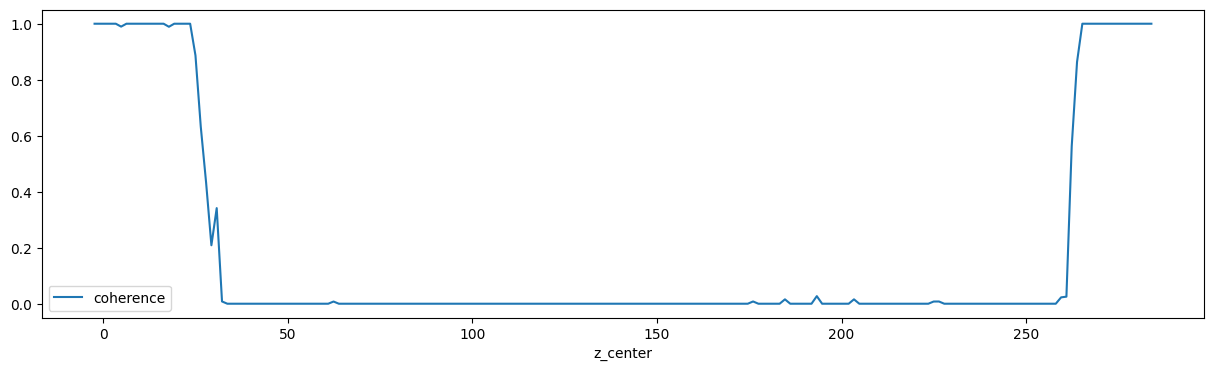

In [41]:
def coherence_binning():
    NUM_BINS = 200

    # print(f"Processing model: {model}")
    _, _, z_coords, cr = compute_dc4("trajectory_labeled_emb_dist.lammpstrj", frame=COH_FRAME)
    preds = np.array(coherence)
    preds = (preds <= 0.83).astype(np.float32)

    bin_edges = np.linspace(
        np.min(z_coords), np.max(z_coords), NUM_BINS + 1
    )
    bin_indices = np.digitize(z_coords, bin_edges) - 1
    bin_liquid_fractions = np.zeros(NUM_BINS)
    bin_cr = np.zeros(NUM_BINS)
    for bin_idx in range(NUM_BINS):
        in_bin = bin_indices == bin_idx
        if np.sum(in_bin) > 0:
            bin_liquid_fractions[bin_idx] = np.mean(preds[in_bin])
            bin_cr[bin_idx] = np.mean(cr[in_bin])
        else:
            bin_liquid_fractions[bin_idx] = np.nan
            bin_cr[bin_idx] = np.nan
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    df = pd.DataFrame({
        "z_center": bin_centers,
        "coherence": bin_liquid_fractions,
        "percent_cr": bin_cr
    })
    df.plot(x="z_center", y="coherence", figsize=(15, 4))
    return df

coh_df = coherence_binning()
    

In [281]:

NUM_BINS = 200

LOADED_PIPELINE = None
LAST_DATA_PATH = None



def run_liquid_binning(data_path):
    # print(f"Processing model: {model}")
    preds, ptm, z_coords, cr = compute_dc4("trajectory_labeled_emb_dist.lammpstrj", frame=300)
    bin_edges = np.linspace(
        np.min(z_coords), np.max(z_coords), NUM_BINS + 1
    )
    bin_indices = np.digitize(z_coords, bin_edges) - 1
    bin_liquid_fractions = np.zeros(NUM_BINS)
    bin_cr = np.zeros(NUM_BINS)
    for bin_idx in range(NUM_BINS):
        in_bin = bin_indices == bin_idx
        if np.sum(in_bin) > 0:
            bin_liquid_fractions[bin_idx] = np.mean(preds[in_bin])
            bin_cr[bin_idx] = np.mean(cr[in_bin])
        else:
            bin_liquid_fractions[bin_idx] = np.nan
            bin_cr[bin_idx] = np.nan
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    df = pd.DataFrame({
        "z_center": bin_centers,
        "liquid_fraction": bin_liquid_fractions,
        "percent_cr": bin_cr
    })
    df.to_csv(f"interface_binning.csv", index=False)

run_liquid_binning("trajectory_labeled_emb_dist.lammpstrj")

<Axes: xlabel='z_center'>

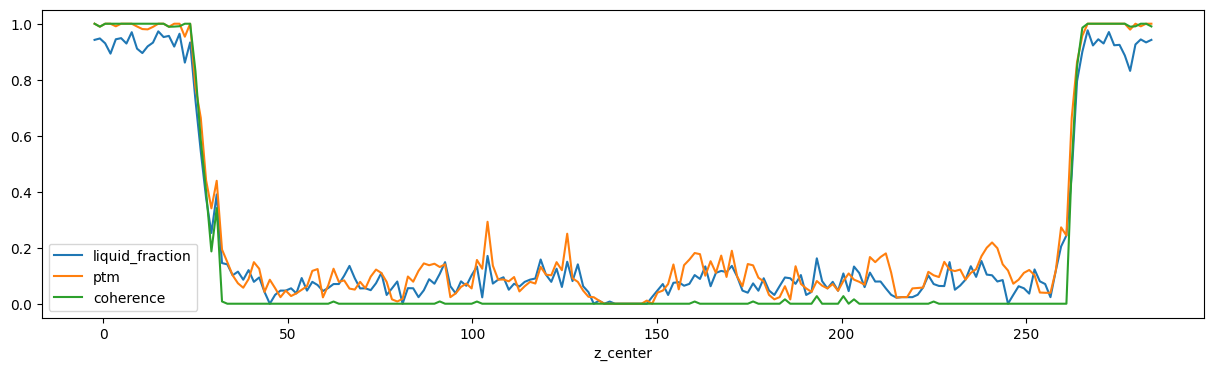

In [282]:
import pandas as pd
df1 = pd.read_csv("interface_binning.csv")
df2 = pd.read_csv("interface_binning_ptm.csv")
df1["ptm"] = df2["liquid_fraction"]
df1["coherence"] = coh_df["coherence"]

df1.plot(x="z_center", y=["liquid_fraction", "ptm", "coherence"], figsize=(15, 4))


In [283]:
ideal = {}

model.eval()
model = model.to(device)

for f in os.listdir("perfect_lattices"):
    pipeline = import_file(os.path.join("perfect_lattices", f))
    lattice = pipeline.compute()

    all_positions = np.copy(lattice.particles.positions)
    _, pos_graph = construct_graph_lists(all_positions, NUM_NEIGHBORS, lattice.cell)

    graph = construct_batched_graph(torch.tensor(pos_graph), None, "cpu")
    struct = f[: f.index(".")]
    
    dl = FastLoader(CrystalDataset(pos_graph, None, None), BATCH_SIZE, "cpu", False)

    latents = []
    for data in dl:
        with torch.inference_mode():
            out = model(data.to(device))[1].cpu()
        latents.append(out)
    
    ideal[struct] = torch.cat(latents).cpu().mean(dim=0)

In [284]:
from ovito.io import import_file, export_file
import torch


pipeline = import_file("dump.r_1100K_1.lammpstrj")  # auto-detects LAMMPS dump format

frame_idx = 300
data = pipeline.compute(frame_idx)

graphs = construct_graph_lists(np.array(data.particles.positions), NUM_NEIGHBORS, data.cell)[1]
dset = CrystalDataset(graphs, None, None)
dloader = FastLoader(dset, BATCH_SIZE, device, False)

In [291]:
model.eval()
model = model.to(device)

all_labels = []

for dat in dloader:
    with torch.inference_mode():
        out = model(dat.to(device))[1].cpu()

    min_dist = torch.zeros(len(out), dtype=torch.float32) + (10 ** 9)

    for _, target in ideal.items():
        dists = ((out - target) ** 2).sum(dim=-1)
        min_dist = torch.min(min_dist, dists)
        
    all_labels.extend(min_dist)

In [289]:
max(all_labels)

tensor(1.2376)

(array([2.970e+02, 1.320e+02, 1.950e+02, 7.260e+02, 1.809e+03, 2.611e+03,
        2.647e+03, 2.196e+03, 1.817e+03, 1.275e+03, 8.210e+02, 6.490e+02,
        4.920e+02, 3.680e+02, 2.750e+02, 2.160e+02, 1.490e+02, 1.320e+02,
        9.900e+01, 7.900e+01, 6.700e+01, 6.400e+01, 6.700e+01, 4.700e+01,
        6.300e+01, 4.700e+01, 4.100e+01, 4.900e+01, 4.500e+01, 5.900e+01,
        3.900e+01, 5.100e+01, 4.000e+01, 3.800e+01, 4.800e+01, 4.600e+01,
        4.900e+01, 3.600e+01, 4.100e+01, 6.000e+01, 4.000e+01, 4.500e+01,
        5.400e+01, 5.000e+01, 5.300e+01, 4.700e+01, 4.700e+01, 5.600e+01,
        4.700e+01, 4.800e+01, 4.500e+01, 5.700e+01, 6.300e+01, 5.800e+01,
        5.800e+01, 5.800e+01, 6.000e+01, 6.700e+01, 5.600e+01, 5.300e+01,
        6.600e+01, 5.300e+01, 6.500e+01, 4.100e+01, 4.400e+01, 5.500e+01,
        6.700e+01, 5.000e+01, 4.700e+01, 5.900e+01, 4.400e+01, 5.000e+01,
        5.900e+01, 6.700e+01, 5.400e+01, 4.900e+01, 5.200e+01, 4.200e+01,
        5.900e+01, 5.500e+01, 5.200e+0

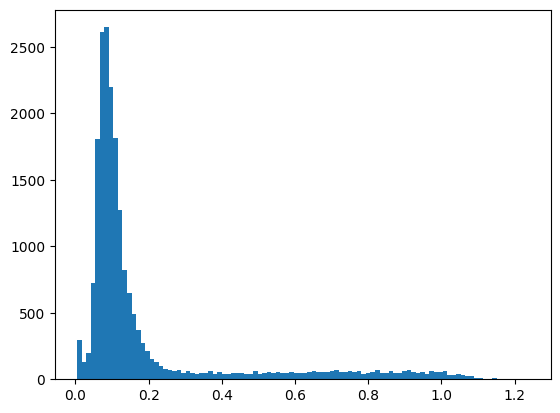

In [290]:
import matplotlib.pyplot as plt
plt.hist(all_labels, bins=100)


In [30]:
# Attach label as particle property
data = data.clone()
data.particles_.create_property("liquid_frac", data=all_labels)

# for prop in data.particles.keys():
    # data.particles[prop].export = True

# -----------------------------------
# 4. Save only this frame
# -----------------------------------
export_file(
    data,
    "frame_300_labeled_emb_dist.lammpstrj",
    format="lammps/dump",
    columns=[
        "Particle Identifier", 
        "Particle Type", 
        "Position.X", 
        "Position.Y", 
        "Position.Z", 
        "liquid_frac"  # Your new custom property
    ]
)

print("Saved: frame_300_labeled_emb_dist.lammpstrj")


Saved: frame_300_labeled_emb_dist.lammpstrj


In [47]:
import numpy as np
from ovito.io import import_file, export_file
from ovito.modifiers import PythonScriptModifier
import torch

# --- ASSUMPTIONS ---
# Assuming 'model', 'device', 'ideal', 'construct_graph_lists', 
# 'CrystalDataset', 'FastLoader', 'NUM_NEIGHBORS', 'BATCH_SIZE' 
# are already defined in your script before this block.

# Load the trajectory
pipeline = import_file("dump.r_1100K_1.lammpstrj")

# Prepare model
model.eval()
model = model.to(device)

# Define the modifier function that runs on EVERY frame
def calculate_liquidness(frame, data):
    # 1. Extract data from current OVITO frame
    # We convert to numpy immediately to avoid keeping OVITO references alive in Torch
    pos = np.array(data.particles.positions)
    
    # 2. Construct Graphs (Your custom logic)
    # Note: We use data.cell directly as you did before
    graphs = construct_graph_lists(pos, NUM_NEIGHBORS, data.cell)[1]
    
    # 3. Prepare Loader
    dset = CrystalDataset(graphs, None, None)
    # shuffle=False is critical so labels match particle order
    dloader = FastLoader(dset, BATCH_SIZE, device, False) 

    all_labels = []

    # 4. Inference Loop
    # We don't need no_grad() if using inference_mode(), but good practice
    with torch.inference_mode():
        for dat in dloader:
            # Forward pass
            # Assuming model returns [prediction, embedding] -> taking index [1]
            out = model(dat.to(device))[1].cpu() 

            # Calculate min squared distance to ideal templates
            # Initialize with a large number
            min_dist = torch.zeros(len(out), dtype=torch.float32) + (10 ** 9)

            for _, target in ideal.items():
                # target must be on CPU because 'out' is on CPU
                # Equation: Squared Euclidean Distance
                dists = ((out - target) ** 2).sum(dim=-1)
                min_dist = torch.min(min_dist, dists)
                
            all_labels.extend(min_dist.numpy())

    # 5. Attach label back to OVITO particle properties
    # We define the property name here. It must match the column name in export.
    data.particles_.create_property("liquidness", data=all_labels)

# Attach the modifier to the pipeline
pipeline.modifiers.append(PythonScriptModifier(function=calculate_liquidness))

# Export the ENTIRE pipeline
# OVITO will automatically iterate through all frames, run the modifier, and append to file.
print("Starting export of all frames...")
export_file(
    pipeline,
    "trajectory_labeled_emb_dist.lammpstrj",
    format="lammps/dump",
    columns=[
        "Particle Identifier", 
        "Particle Type", 
        "Position.X", 
        "Position.Y", 
        "Position.Z", 
        "liquidness"  # Matches the property created in the function
    ],
    multiple_frames=True  # Explicitly enables trajectory writing
)

print("Done!")

Starting export of all frames...
Done!


In [292]:
import numpy as np
from ovito.io import import_file, export_file
from ovito.modifiers import PythonScriptModifier
from scipy.spatial import cKDTree
import torch

# Load trajectory
pipeline = import_file("dump.r_1100K_1.lammpstrj")

model.eval()
model = model.to(device)


def calculate_coherence(frame, data):
    """
    OVITO modifier which:
    1) extracts positions
    2) computes embeddings with your GNN
    3) computes the average dot-product coherence per atom
    4) attaches 'coherence' as a particle property
    """
    # --- Extract atomic positions ---
    pos = np.array(data.particles.positions)  # copy to numpy

    # --- Build graphs ---
    graphs = construct_graph_lists(pos, NUM_NEIGHBORS, data.cell)[1]
    dset = CrystalDataset(graphs, None, None)
    dloader = FastLoader(dset, BATCH_SIZE, device, False)

    # --- Compute embeddings ---
    embeddings = []

    with torch.inference_mode():
        for batch in dloader:
            out = model(batch.to(device))[1].cpu()
            embeddings.extend(out)

    embeddings = np.stack([e.numpy() for e in embeddings])   # (N, D)

    # --- Coherence calculation ---
    # Extract box from OVITO cell
    # cell is 3x4: columns 0-2 = lattice vectors, col 3 = origin
    cell = data.cell.matrix.copy()
    boxsize = np.max(cell[:, :3], axis=1)

    # Periodic wrap — make a copy so OVITO data isn't modified
    wrapped_pos = pos - cell[:, 3]
    wrapped_pos %= boxsize

    # KDTree with PBC, but catch any error
    try:
        tree = cKDTree(wrapped_pos, boxsize=boxsize)
    except Exception as e:
        print(f"[Frame {frame}]: KDTree failed — dropping frame. Reason: {e}")
        data.particles_.count = 0   # Deletes all atoms in this frame
        return

    # If KDTree succeeded:
    neighbors = tree.query(wrapped_pos, k=NUM_NEIGHBORS + 1)[1]


    coherence = []

    for i, neigh in enumerate(neighbors[:, 1:]):  # skip itself
        assert len(neigh) == NUM_NEIGHBORS
        # Compute ⟨ dot(e_i, e_j) ⟩_j
        dots = np.dot(embeddings[neigh], embeddings[i])
        coherence.append(float(dots.mean()))

    # --- Attach property to OVITO ---
    data.particles_.create_property("coherence", data=coherence)


# Add modifier
pipeline.modifiers.append(PythonScriptModifier(function=calculate_coherence))

# Export full trajectory
print("Starting export of all frames...")
export_file(
    pipeline,
    "trajectory_labeled_coherence.lammpstrj",
    format="lammps/dump",
    columns=[
        "Particle Identifier",
        "Particle Type",
        "Position.X",
        "Position.Y",
        "Position.Z",
        "coherence",
    ],
    multiple_frames=True,
)
print("Done!")


Starting export of all frames...


RuntimeError: Export of frame 404 failed, because data pipeline evaluation has failed.
Modifier 'Python script' reported: An exception has occurred.

In [25]:

device = "cuda"
model.eval()

test_indices = use_indices[train_section : train_section + 16384]
test_dataset = CrystalDataset(x_data[test_indices], [y_data[i] for i in test_indices], label_map)
test_loader = FastLoader(test_dataset, BATCH_SIZE, device, shuffle=False)

def test(loader) -> float:
     model.eval()
     correct = 0

     for data in loader:
         out = model(data.to(device))[0]
         pred = out.argmax(dim=1)
         correct += int((pred == data.y).sum())

     return correct / len(loader.dataset)

model = model.to(device)
start = time.time()
test(test_loader)
end = time.time()

print(f"Time per inference on {device}: {((end - start) / len(test_loader.dataset)) * 1000:.5f} ms")

# Cuda: 0.05695 ms
# CPU: 0.18337 ms

# Cuda: 0.06786
# CPU:0.32113



# Cuda: 0.06, 0.77165 (ReLU)
# Cuda: 0.06010 (ReLU)


Time per inference on cuda: 0.08182 ms


In [152]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Collect predictions and labels across entire test set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits = model(batch)[0]
        preds = logits.argmax(dim=-1).cpu().numpy()
        labels = batch.y.cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
print(cm)


[[2680    0    0   11    0    0]
 [   0 2234    0    0    1    0]
 [   2    0 2650   15    0    0]
 [  19    0   23 5219    0    2]
 [   0    0    0    0 2846    0]
 [   0    0    0    0    0  682]]


In [123]:
label_map

{'bcc': 0, 'cd': 1, 'fcc': 2, 'hcp': 3, 'hd': 4, 'sc': 5}

In [42]:
N_USE = 17000
SIM_TEMPERATURE_FRACTIONS = np.round(np.arange(0.04, 1.60 + 0.04, 0.04), 6)

model.eval()
model = model.to(device)

exp_to_result = {}

def compute_feature_for_simulation(file_info: tuple[str, str]):
    set_seed(42)
    exp_name, file_name = file_info
    file_path = f"data/{exp_name}/{file_name}"
    pipeline = import_file(file_path)
    num_frames = pipeline.source.num_frames
    dat = []
    for frame in range(num_frames):
        lattice = pipeline.compute(frame)
        lattice = pipeline.compute()
        all_positions = np.copy(lattice.particles.positions)
        _, graph = construct_graph_lists(all_positions, NUM_NEIGHBORS, lattice.cell)
        dat.extend(graph)
    dat = np.array(dat)
    np.random.shuffle(dat)
    return dat[0 : 17000]

for exp_name in ["li_bcc", "al_fcc", "ge_cd", "ti_hcp"]:
    inference_results = [[] for _ in range(len(SIM_TEMPERATURE_FRACTIONS))]
    
    for test_file in os.listdir(f"data/{exp_name}"):
        data_path = f"data/{exp_name}/{test_file}"
        if "relaxed" in data_path or not data_path.endswith(".gz"):
            continue
        sim_temp_id = test_file[5:-3]
        idx = np.where(SIM_TEMPERATURE_FRACTIONS == float(sim_temp_id))[0][0]

        start_time = time.time()

        graphs = compute_feature_for_simulation((exp_name, test_file))
        dl = FastLoader(CrystalDataset(graphs, [exp_name[exp_name.find("_") + 1 :]] * N_USE, label_map), BATCH_SIZE, device, False)
        
        correct = 0
        for data in dl:
            out = model(data.to(device))[0]
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
        acc = correct / N_USE
        inference_results[idx].append(acc)

        elapsed_time = time.time() - start_time

        print(
            f"Accuracy on {exp_name} {sim_temp_id}: {acc:.2f}, elapsed time: {elapsed_time:.2f}s"
        )
    
    exp_to_result[exp_name] = inference_results

Accuracy on li_bcc 0.04: 1.00, elapsed time: 2.65s
Accuracy on li_bcc 0.08: 1.00, elapsed time: 2.45s
Accuracy on li_bcc 0.12: 1.00, elapsed time: 1.93s
Accuracy on li_bcc 0.16: 1.00, elapsed time: 1.97s
Accuracy on li_bcc 0.2: 1.00, elapsed time: 1.93s
Accuracy on li_bcc 0.24: 1.00, elapsed time: 1.97s
Accuracy on li_bcc 0.28: 1.00, elapsed time: 1.94s
Accuracy on li_bcc 0.32: 1.00, elapsed time: 1.99s
Accuracy on li_bcc 0.36: 1.00, elapsed time: 1.98s
Accuracy on li_bcc 0.4: 1.00, elapsed time: 1.92s
Accuracy on li_bcc 0.44: 1.00, elapsed time: 1.98s
Accuracy on li_bcc 0.48: 1.00, elapsed time: 2.04s
Accuracy on li_bcc 0.52: 1.00, elapsed time: 1.93s
Accuracy on li_bcc 0.56: 1.00, elapsed time: 1.94s
Accuracy on li_bcc 0.6: 1.00, elapsed time: 1.93s
Accuracy on li_bcc 0.64: 1.00, elapsed time: 1.93s
Accuracy on li_bcc 0.68: 1.00, elapsed time: 1.93s
Accuracy on li_bcc 0.72: 0.99, elapsed time: 1.90s
Accuracy on li_bcc 0.76: 0.99, elapsed time: 1.94s
Accuracy on li_bcc 0.8: 0.99, elap

In [44]:
for exp_name in ["al_fcc", "li_bcc", "ge_cd", "ti_hcp"]:
    df = pd.read_csv(f"results/{exp_name}_results.csv", index_col="Simulation Temperature Fraction")
    df["nequip emb 32 flip ported"] = np.array(exp_to_result[exp_name])[:, 0]
    df.to_csv(f"results/{exp_name}_results.csv", index_label="Simulation Temperature Fraction")

In [28]:

N_USE = 17000
device = "cuda"

def compute_feature_for_simulation(file_info):
    # Random seed
    np.random.seed(42)

    # Get information about the file
    exp_name, file_name = file_info

    # Get lattices
    file_path = f"data/{exp_name}/{file_name}"
    pipeline = import_file(file_path)

    # Iterate over each saved lattice
    num_frames = pipeline.source.num_frames
    dat = []

    for frame in range(num_frames):
        lattice = pipeline.compute(frame)
        lattice = pipeline.compute()

        all_positions = np.copy(lattice.particles.positions)


        """
        # Add one to include self
        tree = cKDTree(all_positions)
        neighbors = tree.query(all_positions, k=16 + 1)[1][:]
        temp = []
        # Each X will store all nearest neighbor positions with the first one being the central atom
        for neigh in neighbors:
            temp.append(np.array([all_positions[i] for i in neigh]))
        """

        _, graph = construct_graph_lists(all_positions, NUM_NEIGHBORS, lattice.cell)
        dat.extend(graph)
        print(lattice.cell[:, :3])

    
    dat = np.array(dat)
    np.random.shuffle(dat)
    return dat[0 : 17000]

md_testing_data = []
md_data_loader = []

for exp in ["dump_0.24.gz", "dump_0.36.gz", "dump_0.96.gz", "dump_1.12.gz"]:
    md_testing_data.append(compute_feature_for_simulation(("al_fcc", exp)))
    md_data_loader.append(FastLoader(CrystalDataset(md_testing_data[-1], ["fcc"] * 17000, label_map), BATCH_SIZE, device, False))

for structure in ["ge_cd", "li_bcc", "ti_hcp"]:
    for exp in ["dump_1.0.gz"]:
        md_testing_data.append(compute_feature_for_simulation((structure, exp)))
        md_data_loader.append(FastLoader(CrystalDataset(md_testing_data[-1], [structure[3:]] * 17000, label_map), BATCH_SIZE, device, False))

[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.64180921  0.        ]
 [ 0.          0.         40.64180921]]
[[40.64180921  0.          0.        ]
 [ 0.         40.

In [ ]:
def test_md() -> float:
    model.eval()
    accs = []

    with torch.no_grad():
        for dl in md_data_loader:
            correct = 0

            for data in dl:
                out = model(data.to(device))[0]
                pred = out.argmax(dim=1)
                correct += int((pred == data.y).sum())

            accs.append(correct / N_USE)

    return accs

# Beat: [1.0, 0.9992941176470588, 0.9945294117647059, 0.9812941176470589, 0.9999411764705882, 0.8994705882352941, 0.9539411764705882]
print(test_md())

# Beaten: [0.9997058823529412, 0.9996470588235294, 0.9963529411764706, 0.9814705882352941, 1.0, 0.9010588235294118, 0.9690588235294118]
#        [1.0, 1.0, 0.993764705882353, 0.9783529411764705, 1.0, 0.8569411764705882, 0.977]

# Try 1:
# [0.967, 0.9687058823529412, 0.9482941176470588, 0.9314705882352942, 0.9698823529411764, 0.5559411764705883, 0.8576470588235294]



[1.0, 1.0, 0.993764705882353, 0.9783529411764705, 1.0, 0.8569411764705882, 0.977]


In [ ]:
vals = []

for d in all_dists:
    vals.extend(d.tolist())  # extend with scalars, not tensors

vals.sort()
q = vals[int(len(vals) * 0.99)]
print(q)

In [ ]:


test = torch.tensor(x_data[: 1024]).float()

start = time.time()
for i in range(100):
    construct_batched_graph(test, None, 24, "cuda")
end = time.time()

print(f"Time per call on gpu: {((end - start) / (100 * 1024)) * 1000:.5f} ms")

ValueError: expected sequence of length 2000 at dim 1 (got 1728)

In [ ]:
spherical_harmonics("1x0e+1x1e+1x2e+1x3e+1x4e", torch.tensor([[1.0, 2.0, 3.0], [0.0, 0.0, 0.0]]), normalize=True)

tensor([[ 0.2821,  0.1306,  0.2612,  0.3918,  0.2341,  0.1561, -0.0451,  0.4682,
          0.3122,  0.2929,  0.3311,  0.0524, -0.3135,  0.1571,  0.4415,  0.2028,
          0.3065,  0.4696,  0.2028, -0.0956, -0.2871, -0.2867,  0.2703,  0.3251,
          0.0894],
        [ 0.2821,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000]])

In [ ]:
lin = Linear("6x0e", "1x0e")
x = torch.tensor([1, 2, 3])

In [ ]:
Irreps("1x0e + 1x0e") == Irreps("2x0e")

False

In [ ]:
g = Gate("16x0o", [torch.tanh], "32x0o", [torch.tanh], "16x1e+16x1o")
g.irreps_out

16x0o+16x1o+16x1e

In [ ]:
x = Irreps("4x0e + 8x1e")
y = Irreps("100x0e + 100x1e")
out = Irreps("3x0e + 6x1e")

In [ ]:
o3.FullTensorProduct(x, y)

FullTensorProduct(4x0e+8x1e x 100x0e+100x1e -> 1200x0e+2000x1e+800x2e | 4000 paths | 0 weights)

In [ ]:
o3.FullyConnectedTensorProduct(x, y, out)

FullyConnectedTensorProduct(4x0e+8x1e x 100x0e+100x1e -> 3x0e+6x1e | 15600 paths | 15600 weights)

In [ ]:
irreps_mid = []
instructions = []

for i, (mul1, ir_in) in enumerate(x):
    for j, (mul2, ir_out) in enumerate(y):
        for ir_out in ir_in * ir_out:
            if ir_out in out:
                k = len(irreps_mid)
                irreps_mid.append((mul1, ir_out))
                instructions.append((i, j, k, 'uvu', True))


In [ ]:
irreps_mid = o3.Irreps(irreps_mid)
irreps_mid

4x0e+4x1e+8x1e+8x0e+8x1e

In [ ]:
irreps_mid, p, _ = irreps_mid.sort()
irreps_mid, p

(4x0e+8x0e+4x1e+8x1e+8x1e, (0, 2, 3, 1, 4))

In [ ]:
instructions = [
            (i_1, i_2, p[i_out], mode, train)
            for i_1, i_2, i_out, mode, train in instructions
        ]
instructions

[(0, 0, 0, 'uvu', True),
 (0, 1, 2, 'uvu', True),
 (1, 0, 3, 'uvu', True),
 (1, 1, 1, 'uvu', True),
 (1, 1, 4, 'uvu', True)]

In [ ]:
conv = o3.TensorProduct(
            x,
            y,
            irreps_mid,
            instructions,
            internal_weights = False,
            shared_weights   = False,
        )

(<Figure size 640x480 with 1 Axes>, <Axes: >)

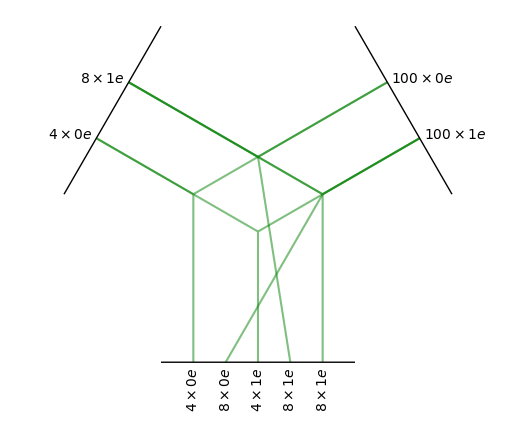

In [ ]:
conv.visualize()

In [ ]:
conv.weight_numel

3200

In [ ]:
conv.weight_view_for_instruction(4, torch.ones(1, 32))
# (1, 1, 4, 'uvu', True)
# 8x1e

AssertionError: Invalid weight shape

In [ ]:
list(conv.weight_views(torch.ones(1, 32)))

[tensor([[[1.],
          [1.],
          [1.],
          [1.]]]),
 tensor([[[1.],
          [1.],
          [1.],
          [1.]]]),
 tensor([[[1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.]]]),
 tensor([[[1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.]]]),
 tensor([[[1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.],
          [1.]]])]

In [ ]:
module = o3.TensorProduct(
    "2x1o", "16x1o", "2x1e",
    [
        (0, 0, 0, "uvu", True)
    ]
)
module.weight_numel

32

In [ ]:
list(module.weight_views(torch.zeros((module.weight_numel))))

[tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])]